# GPS Correction Model Comparison Pipeline
This notebook replicates the GPS correction pipeline, trains multiple models for comparison, and uses a filtered subset (100,000 samples) of high-quality data.

In [7]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
import joblib
import glob
import os
import random
from pyproj import Transformer
# Optional: XGBoost and LightGBM
try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None
try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

## 2. Load and Filter Dataset (100k Samples)
Load the available high-quality GPS correction data and randomly sample 100,000 rows for model comparison.

In [8]:
# Load and filter high-quality GPS correction data
# Replicating v6 pipeline: load, merge, filter, transform, and engineer features
import glob
import os
from pyproj import Transformer

base_path = 'smartphone-decimeter-2023/sdc2023/train/'
drive_sets = []
for drive in glob.glob(os.path.join(base_path, '*')):
    if not os.path.isdir(drive):
        continue
    for phone in glob.glob(os.path.join(drive, '*')):
        if not os.path.isdir(phone):
            continue
        gnss = os.path.join(phone, 'device_gnss.csv')
        imu = os.path.join(phone, 'device_imu.csv')
        gt = os.path.join(phone, 'ground_truth.csv')
        if os.path.exists(gnss) and os.path.exists(imu) and os.path.exists(gt):
            drive_sets.append({'gnss': gnss, 'imu': imu, 'gt': gt, 'drive': drive, 'phone': phone})
print(f"Found {len(drive_sets)} drive/phone sets with all required files.")

transformer = Transformer.from_crs("EPSG:4978", "EPSG:4326", always_xy=True)

X_all = []
y_all = []
total_rows = 0
max_rows = 100000
for i, drive_set in enumerate(drive_sets):
    if total_rows >= max_rows:
        break
    try:
        gnss = pd.read_csv(drive_set['gnss'], low_memory=False)
        imu = pd.read_csv(drive_set['imu'])
        gt = pd.read_csv(drive_set['gt'])
        if 'UnixTimeMillis' in gnss.columns:
            gnss = gnss.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
        if 'UnixTimeMillis' in imu.columns:
            imu = imu.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
        if 'UnixTimeMillis' in gt.columns:
            gt = gt.rename(columns={'UnixTimeMillis': 'utcTimeMillis'})
        if 'MessageType' in imu.columns:
            imu.rename(columns={'MessageType': 'IMU_MessageType'}, inplace=True)
        gnss_imu = pd.merge_asof(
            gnss.sort_values('utcTimeMillis'),
            imu.sort_values('utcTimeMillis'),
            on='utcTimeMillis',
            direction='nearest',
            tolerance=50
        )
        data = pd.merge_asof(
            gnss_imu.sort_values('utcTimeMillis'),
            gt.sort_values('utcTimeMillis'),
            on='utcTimeMillis',
            direction='nearest',
            tolerance=50
        ).dropna(subset=['LatitudeDegrees', 'LongitudeDegrees'])
        # Quality filters
        quality_filters = []
        if 'Cn0DbHz' in data.columns:
            quality_filters.append(data['Cn0DbHz'] > 40)
        if 'SvElevationDegrees' in data.columns:
            quality_filters.append(data['SvElevationDegrees'] > 20)
        valid_ecef = (
            (data['WlsPositionXEcefMeters'] != 0) &
            (data['WlsPositionYEcefMeters'] != 0) &
            (data['WlsPositionZEcefMeters'] != 0) &
            data['WlsPositionXEcefMeters'].notna() &
            data['WlsPositionYEcefMeters'].notna() &
            data['WlsPositionZEcefMeters'].notna()
        )
        quality_filters.append(valid_ecef)
        if quality_filters:
            high_quality_mask = np.logical_and.reduce(quality_filters)
            data = data[high_quality_mask]
        if len(data) == 0:
            continue
        # ECEF to lat/lng
        wls_coords = transformer.transform(
            data['WlsPositionXEcefMeters'].values,
            data['WlsPositionYEcefMeters'].values,
            data['WlsPositionZEcefMeters'].values
        )
        wls_lat = wls_coords[1]
        wls_lng = wls_coords[0]
        valid_coords = (
            np.isfinite(wls_lat) & np.isfinite(wls_lng) &
            (np.abs(wls_lat) <= 90) & (np.abs(wls_lng) <= 180)
        )
        if not np.any(valid_coords):
            continue
        data = data[valid_coords]
        wls_lat = wls_lat[valid_coords]
        wls_lng = wls_lng[valid_coords]
        # Correction offsets
        lat_corrections = data['LatitudeDegrees'].values - wls_lat
        lng_corrections = data['LongitudeDegrees'].values - wls_lng
        correction_magnitude = np.sqrt(lat_corrections**2 + lng_corrections**2) * 111000
        reasonable_corrections = correction_magnitude < 500
        valid_corrections = (
            np.isfinite(lat_corrections) &
            np.isfinite(lng_corrections) &
            reasonable_corrections
        )
        if not np.any(valid_corrections):
            continue
        data = data[valid_corrections]
        lat_corrections = lat_corrections[valid_corrections]
        lng_corrections = lng_corrections[valid_corrections]
        # Speed filter
        if 'SpeedMps' in data.columns:
            data = data[data['SpeedMps'] <= 15.0]
            if len(data) == 0:
                continue
            wls_coords = transformer.transform(
                data['WlsPositionXEcefMeters'].values,
                data['WlsPositionYEcefMeters'].values,
                data['WlsPositionZEcefMeters'].values
            )
            wls_lat = wls_coords[1]
            wls_lng = wls_coords[0]
            lat_corrections = data['LatitudeDegrees'].values - wls_lat
            lng_corrections = data['LongitudeDegrees'].values - wls_lng
        # Derived features
        if 'Cn0DbHz' in data.columns and 'SvElevationDegrees' in data.columns:
            data['SignalQuality'] = data['Cn0DbHz'] * np.sin(np.radians(data['SvElevationDegrees']))
        if 'WlsPositionXEcefMeters' in data.columns:
            data['WLS_Distance'] = np.sqrt(data['WlsPositionXEcefMeters']**2 + data['WlsPositionYEcefMeters']**2 + data['WlsPositionZEcefMeters']**2)
        data = data.fillna(0)
        X = data[[
            'Cn0DbHz', 'Svid', 'SvElevationDegrees', 'SvAzimuthDegrees',
            'IMU_MessageType', 'MeasurementX', 'MeasurementY', 'MeasurementZ',
            'BiasX', 'BiasY', 'BiasZ', 'SpeedMps',
            'WlsPositionXEcefMeters', 'WlsPositionYEcefMeters', 'WlsPositionZEcefMeters',
            'SignalQuality', 'WLS_Distance'
        ]].copy()
        y = pd.DataFrame({
            'LatCorrection': lat_corrections,
            'LngCorrection': lng_corrections
        })
        rows_to_add = min(max_rows - total_rows, len(X))
        if rows_to_add > 0:
            X_all.append(X.iloc[:rows_to_add])
            y_all.append(y.iloc[:rows_to_add])
            total_rows += rows_to_add
    except Exception as e:
        continue

# Concatenate all sets
if len(X_all) == 0:
    print("No valid data found.")
    X_sample = pd.DataFrame()
    y_sample = pd.DataFrame()
else:
    X_sample = pd.concat(X_all, ignore_index=True)
    y_sample = pd.concat(y_all, ignore_index=True)
    print(f"Selected {len(X_sample):,} contiguous rows for model comparison")

Found 156 drive/phone sets with all required files.
Selected 100,000 contiguous rows for model comparison
Selected 100,000 contiguous rows for model comparison


## 3. Preprocess Data
Handle missing values, encode categorical variables, and scale features as needed for model training.

In [9]:
# Preprocess features and target
# Select features (including derived features) and target columns
feature_cols = [
    'Cn0DbHz', 'Svid', 'SvElevationDegrees', 'SvAzimuthDegrees',
    'IMU_MessageType', 'MeasurementX', 'MeasurementY', 'MeasurementZ',
    'BiasX', 'BiasY', 'BiasZ', 'SpeedMps',
    'WlsPositionXEcefMeters', 'WlsPositionYEcefMeters', 'WlsPositionZEcefMeters',
    'SignalQuality', 'WLS_Distance'
]
target_cols = ['LatCorrection', 'LngCorrection']

# Use X_sample and y_sample from previous cell
X = X_sample[feature_cols].fillna(0)
y = y_sample[target_cols].fillna(0)

# Encode categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

# Scale features
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

## 4. Split Data into Train and Test Sets
Split the filtered and preprocessed dataset into training and testing sets for model evaluation.

In [10]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")

Training samples: 80,000
Testing samples: 20,000


## 5. Train Multiple Models for Comparison
Train several regression models (Linear Regression, Random Forest, Gradient Boosting, XGBoost, LightGBM) on the training data.

In [11]:
# Train multiple regression models
from sklearn.multioutput import MultiOutputRegressor
models = {}

# Linear Regression (supports multi-output natively)
lr = LinearRegression()
lr.fit(X_train, y_train)
models['Linear Regression'] = lr

# Random Forest (supports multi-output natively)
rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
models['Random Forest'] = rf

# Gradient Boosting (wrap for multi-output)
gb = MultiOutputRegressor(GradientBoostingRegressor(n_estimators=200, max_depth=8, learning_rate=0.05, random_state=42))
gb.fit(X_train, y_train)
models['Gradient Boosting'] = gb

# XGBoost (wrap for multi-output if available)
if XGBRegressor:
    xgb = MultiOutputRegressor(XGBRegressor(n_estimators=200, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1))
    xgb.fit(X_train, y_train)
    models['XGBoost'] = xgb

# LightGBM (wrap for multi-output if available)
if LGBMRegressor:
    lgbm = MultiOutputRegressor(LGBMRegressor(n_estimators=200, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1))
    lgbm.fit(X_train, y_train)
    models['LightGBM'] = lgbm

print(f"Trained models: {list(models.keys())}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001958 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3194
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 17
[LightGBM] [Info] Start training from score -0.000008
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3194
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 17
[LightGBM] [Info] Start training from score -0.000002
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not eno

## 6. Evaluate Model Performance
Evaluate each model on the test set using RMSE, MAE, and R² for both latitude and longitude corrections.

In [16]:
# Evaluate model performance
results = []
for name, model in models.items():
    # For LightGBM, pass DataFrame with feature names to suppress warning
    if name == 'LightGBM':
        y_pred = model.predict(pd.DataFrame(X_test, columns=X.columns))
    else:
        y_pred = model.predict(X_test)
    # If multioutput, y_pred is (n_samples, 2)
    rmse_lat = np.sqrt(mean_squared_error(y_test['LatCorrection'], y_pred[:, 0])) * 111000
    rmse_lng = np.sqrt(mean_squared_error(y_test['LngCorrection'], y_pred[:, 1])) * 111000
    mae_lat = mean_absolute_error(y_test['LatCorrection'], y_pred[:, 0]) * 111000
    mae_lng = mean_absolute_error(y_test['LngCorrection'], y_pred[:, 1]) * 111000
    r2_lat = r2_score(y_test['LatCorrection'], y_pred[:, 0])
    r2_lng = r2_score(y_test['LngCorrection'], y_pred[:, 1])
    results.append({
        'Model': name,
        'RMSE_Lat (m)': rmse_lat,
        'RMSE_Lng (m)': rmse_lng,
        'MAE_Lat (m)': mae_lat,
        'MAE_Lng (m)': mae_lng,
        'R2_Lat': r2_lat,
        'R2_Lng': r2_lng
    })
results_df = pd.DataFrame(results)
print(results_df)

# Determine best overall model based on average RMSE (meters)
results_df['Avg_RMSE (m)'] = (results_df['RMSE_Lat (m)'] + results_df['RMSE_Lng (m)']) / 2
sorted_df = results_df.sort_values('Avg_RMSE (m)')
print("\nBest models from first to last (lowest Avg_RMSE to highest):")
for i, row in sorted_df.iterrows():
    print(f"{i+1}. {row['Model']} (Avg_RMSE: {row['Avg_RMSE (m)']:.2f} m)")

best_model = sorted_df.iloc[0]['Model']
best_rmse = sorted_df.iloc[0]['Avg_RMSE (m)']
print(f"\nBest overall model: {best_model} (Avg_RMSE: {best_rmse:.2f} m)")

print("\nWhy RMSE was used:")
print("RMSE (Root Mean Squared Error) is the primary metric because it penalizes larger errors more heavily, providing a clear measure of overall prediction accuracy in meters. In GPS correction, minimizing large errors is critical for reliable positioning, so the model with the lowest average RMSE across latitude and longitude corrections is considered the best overall.")

               Model  RMSE_Lat (m)  RMSE_Lng (m)  MAE_Lat (m)  MAE_Lng (m)  \
0  Linear Regression      3.789259      2.938694     1.725638     1.855794   
1      Random Forest      1.682062      1.847144     1.231199     1.354945   
2  Gradient Boosting      1.231332      1.440711     0.916135     1.029858   
3            XGBoost      3.631655      2.964354     1.751756     1.924652   
4           LightGBM      1.555200      1.785096     1.128948     1.236368   

     R2_Lat    R2_Lng  
0  0.021730  0.066367  
1  0.807232  0.631134  
2  0.896700  0.775601  
3  0.101415  0.049991  
4  0.835213  0.655499  

Best models from first to last (lowest Avg_RMSE to highest):
3. Gradient Boosting (Avg_RMSE: 1.34 m)
5. LightGBM (Avg_RMSE: 1.67 m)
2. Random Forest (Avg_RMSE: 1.76 m)
4. XGBoost (Avg_RMSE: 3.30 m)
1. Linear Regression (Avg_RMSE: 3.36 m)

Best overall model: Gradient Boosting (Avg_RMSE: 1.34 m)

Why RMSE was used:
RMSE (Root Mean Squared Error) is the primary metric because it penali

## 7. Visualize Model Comparison Results
Create bar charts to compare RMSE, MAE, and R² across models for both latitude and longitude corrections.

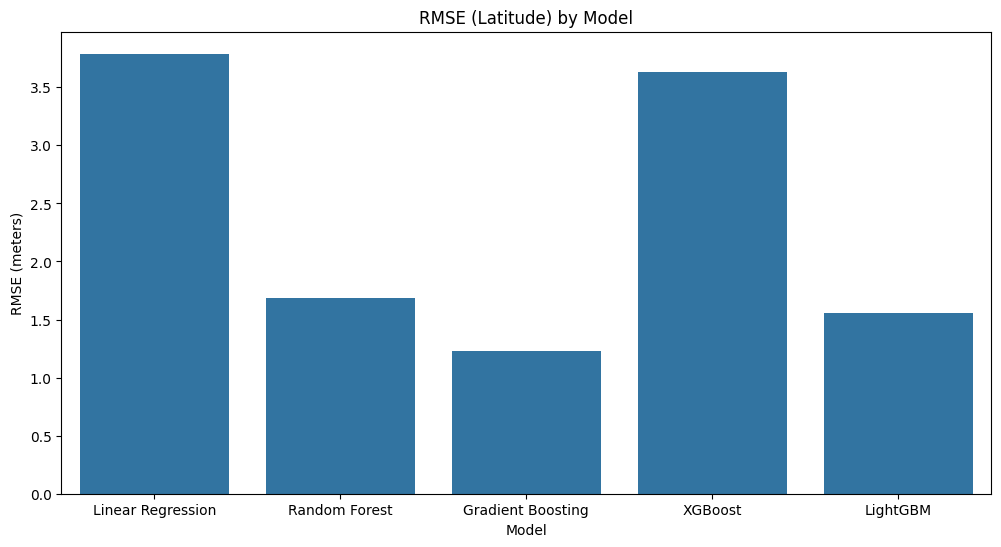

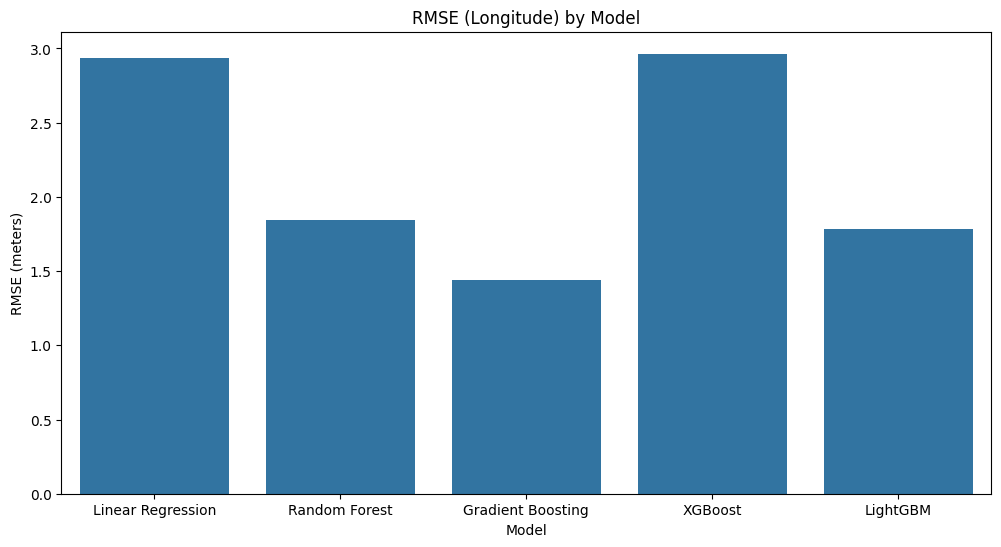

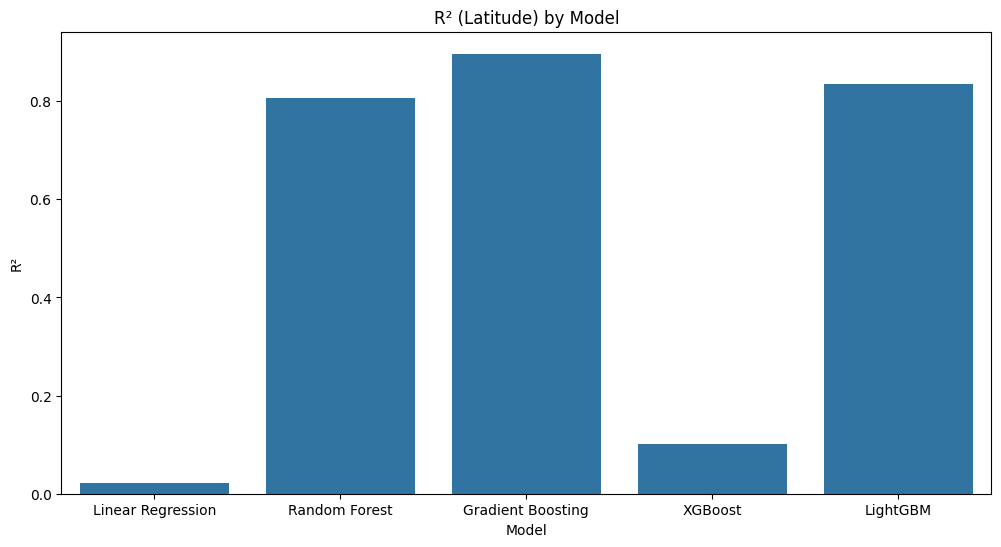

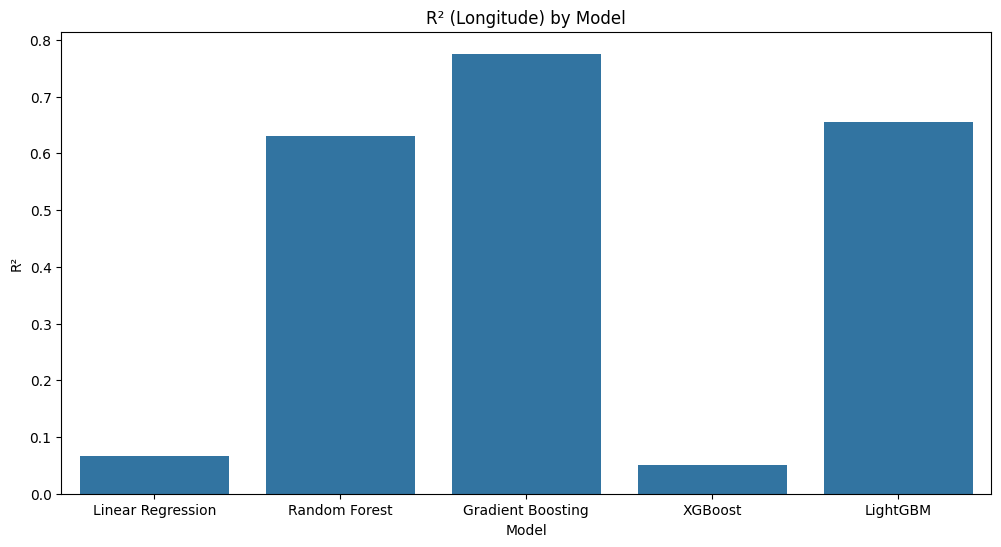

In [15]:
# Visualize model comparison results
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='RMSE_Lat (m)', data=results_df)
plt.title('RMSE (Latitude) by Model')
plt.ylabel('RMSE (meters)')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='RMSE_Lng (m)', data=results_df)
plt.title('RMSE (Longitude) by Model')
plt.ylabel('RMSE (meters)')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R2_Lat', data=results_df)
plt.title('R² (Latitude) by Model')
plt.ylabel('R²')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R2_Lng', data=results_df)
plt.title('R² (Longitude) by Model')
plt.ylabel('R²')
plt.show()